# Validity checks — reconstructibility, convergent validity, G-theory

**Question Noah is going to ask:** what does "valid" mean for an LLM-judge aspect?

Three operationalisations, one notebook:

1. **Reconstructibility** — does a single aspect's score recover the human label? AUC > 0.5 means yes.
   Aspects that score near 0.5 are non-discriminative noise; aspects far from 0.5 are the ones a judge can latch onto.
2. **Convergent validity (paraphrase stability)** — when the *rubric text* is paraphrased (p0 / p1 / p2),
   does the same datapoint score the same? High ρ̄ across paraphrases means the aspect measures
   the property, not the prose.
3. **G-theory variance decomposition** — pool every Claude+Qwen score and ask: how much variance
   sits at each facet (datapoint, aspect, judge, paraphrase)? Small σ²(judge) + σ²(paraphrase) means
   our rubric machinery is reliable across those facets; large σ²(aspect) means aspects discriminate.

All three pull from `outputs/v2_db/cells_v1/` (canonical cells DB).


In [1]:
import json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

REPO = Path('/Users/spangher/Projects/stanford-research/norm-research')
OUT  = REPO / 'outputs/noah_meeting'

TASKS = ['peer_review','math','notice_and_comment','press_releases','humor',
         'news_homepages','patents','code_review','creative_writing']
TASK_PRETTY = {
    'peer_review':'Peer review', 'math':'Math',
    'notice_and_comment':'Notice & comment', 'press_releases':'Press releases',
    'humor':'Humor', 'news_homepages':'News homepages',
    'patents':'Patents', 'code_review':'Code review',
    'creative_writing':'Creative writing'}

# Load the three CSVs the upstream script wrote
recon = pd.read_csv(OUT/'reconstructibility.csv')
conv  = pd.read_csv(OUT/'convergent_validity.csv')
gth   = pd.read_csv(OUT/'g_theory.csv')

print(f'recon: {recon.shape}')
print(f'conv:  {conv.shape}')
print(f'gth:   {gth.shape}')
recon.head()

recon: (1215, 6)
conv:  (1036, 8)
gth:   (9, 7)


,task,aspect_id,name,auc,reconstructibility,n
0,peer_review,a94,Conflicts of Interest and Funding Disclosure,0.500,0.000,30
1,peer_review,a0,Methodological Rigor and Soundness,0.498,0.002,79
2,peer_review,a3,Transparency and Complete Reporting,0.593,0.093,78
3,peer_review,a12,Statistical Methodology and Reporting,0.543,0.043,78
4,peer_review,a13,Sample Size and Power,0.540,0.040,68


## 1. Reconstructibility — single-aspect score → human label

For every (task, aspect), pivot Claude p0 scores by datapoint, hand them to a single-feature ROC,
and record `AUC` plus `|AUC − 0.5|` (reconstructibility). High = the aspect alone carries label signal.
Low = chance-level, the aspect doesn't matter (or it's noise).

The columns flagged with arrows show whether the aspect *correlates* with the label (AUC > 0.5)
or *anti-correlates* (AUC < 0.5); both are informative.


In [2]:
def style_recon(df, top=True, n=5):
    arrow = lambda a: '↑' if a >= 0.5 else '↓'
    color = lambda a: '#0a7a3e' if a >= 0.5 else '#b03030'
    rows_html = []
    for _, r in df.iterrows():
        rows_html.append(
            f'<tr>'
            f'<td style="font-family:monospace;color:#666">{r["aspect_id"]}</td>'
            f'<td>{(r["name"] or "?")[:60]}</td>'
            f'<td style="text-align:right;font-variant-numeric:tabular-nums;color:{color(r["auc"])};font-weight:600">{arrow(r["auc"])} {r["auc"]:.3f}</td>'
            f'<td style="text-align:right;font-variant-numeric:tabular-nums">{r["reconstructibility"]:.3f}</td>'
            f'<td style="text-align:right;color:#888;font-variant-numeric:tabular-nums">n={int(r["n"])}</td>'
            f'</tr>')
    return ''.join(rows_html)

def two_col_html(task_pretty, top_df, bot_df):
    cols = []
    for label, df, accent in [('Top 5 most reconstructible', top_df, '#0070c0'),
                              ('Bottom 5 (least reconstructible)', bot_df, '#888')]:
        cols.append(f'''
            <div style="flex:1;background:#fafbfd;padding:14px 16px;border-radius:6px;border-left:3px solid {accent}">
              <div style="font-size:11px;text-transform:uppercase;letter-spacing:1.3px;color:{accent};font-weight:700;margin-bottom:8px">{label}</div>
              <table style="width:100%;border-collapse:collapse;font-size:13px">
                <thead><tr style="color:#666;font-size:10px;text-transform:uppercase;letter-spacing:1px">
                  <th style="text-align:left;padding:4px 6px">id</th><th style="text-align:left">name</th>
                  <th style="text-align:right">AUC</th><th style="text-align:right">|Δ½|</th><th style="text-align:right">n</th></tr></thead>
                <tbody>{style_recon(df)}</tbody>
              </table>
            </div>''')
    return f'''
        <div style="margin-bottom:24px">
          <h3 style="margin:0 0 10px 0;color:#1a1a1a;border-bottom:2px solid #222;padding-bottom:6px">{task_pretty}</h3>
          <div style="display:flex;gap:16px">{''.join(cols)}</div>
        </div>'''

html_blocks = []
for t in TASKS:
    sub = recon[recon['task']==t].copy()
    if sub.empty: continue
    sub = sub.sort_values('reconstructibility', ascending=False)
    top = sub.head(5)
    bot = sub.tail(5).sort_values('reconstructibility', ascending=True)
    html_blocks.append(two_col_html(TASK_PRETTY[t], top, bot))

display(HTML('<div style="font-family:-apple-system,Helvetica,Arial,sans-serif;max-width:1200px">'
             + ''.join(html_blocks) + '</div>'))

id,name,AUC,|Δ½|,n
a103,Repository Documentation and Standards,↑ 0.699,0.199,n=46
a100,Licensing and Open Access of Outputs,↑ 0.682,0.182,n=38
a179,Responsible Release and Publication Strategy,↑ 0.674,0.174,n=34
a24,Source Data Definition,↑ 0.659,0.159,n=71
a121,Reproducibility and Resource Identification,↑ 0.653,0.153,n=70
id,name,AUC,|Δ½|,n
a46,Conceptual Understanding Demonstration,↑ 0.500,0.000,n=80
a216,Capitalization Conventions,↑ 0.500,0.000,n=100
a79,Internal Consistency,↑ 0.500,0.000,n=36
a178,Research Guidance and Oversight,↑ 0.500,0.000,n=80


## 2. Convergent validity — score stability across paraphrased rubrics

Same datapoint, same aspect, different paraphrase of the rubric (p0/p1/p2). High Pearson ρ̄ across
the pairwise comparisons means the aspect is robust to surface rewording — it measures the property,
not the prose.

Bottom-5 = aspects whose score flips when we paraphrase the rubric — the prose itself was doing
the work. These are the danger zone for an LLM-judge.


In [3]:
def style_conv(df):
    rows_html = []
    for _, r in df.iterrows():
        rho = r['mean_rho_across_paraphrases']
        color = '#0070c0' if rho >= 0.5 else ('#aa6600' if rho >= 0.3 else '#b03030')
        rows_html.append(
            f'<tr>'
            f'<td style="font-family:monospace;color:#666">{r["aspect_id"]}</td>'
            f'<td>{(r["name"] or "?")[:60]}</td>'
            f'<td style="text-align:right;font-variant-numeric:tabular-nums;color:{color};font-weight:600">{rho:+.3f}</td>'
            f'</tr>')
    return ''.join(rows_html)

def two_col_conv(task_pretty, top_df, bot_df):
    cols = []
    for label, df, accent in [('Top 5 most convergent', top_df, '#0070c0'),
                              ('Bottom 5 (least convergent)', bot_df, '#b03030')]:
        cols.append(f'''
            <div style="flex:1;background:#fafbfd;padding:14px 16px;border-radius:6px;border-left:3px solid {accent}">
              <div style="font-size:11px;text-transform:uppercase;letter-spacing:1.3px;color:{accent};font-weight:700;margin-bottom:8px">{label}</div>
              <table style="width:100%;border-collapse:collapse;font-size:13px">
                <thead><tr style="color:#666;font-size:10px;text-transform:uppercase;letter-spacing:1px">
                  <th style="text-align:left;padding:4px 6px">id</th><th style="text-align:left">name</th>
                  <th style="text-align:right">ρ̄</th></tr></thead>
                <tbody>{style_conv(df)}</tbody>
              </table>
            </div>''')
    return f'''
        <div style="margin-bottom:24px">
          <h3 style="margin:0 0 10px 0;color:#1a1a1a;border-bottom:2px solid #222;padding-bottom:6px">{task_pretty}</h3>
          <div style="display:flex;gap:16px">{''.join(cols)}</div>
        </div>'''

html_blocks = []
for t in TASKS:
    sub = conv[conv['task']==t].copy()
    if sub.empty: continue
    sub = sub.sort_values('mean_rho_across_paraphrases', ascending=False)
    top = sub.head(5)
    bot = sub.tail(5).sort_values('mean_rho_across_paraphrases', ascending=True)
    html_blocks.append(two_col_conv(TASK_PRETTY[t], top, bot))

display(HTML('<div style="font-family:-apple-system,Helvetica,Arial,sans-serif;max-width:1200px">'
             + ''.join(html_blocks) + '</div>'))

id,name,ρ̄
a147,Review Process Integrity,+1.000
a32,Mathematical and Algorithmic Description,+0.919
a151,?,+0.895
a5,Data and Code Availability,+0.841
a123,Novelty and Original Contribution,+0.819
id,name,ρ̄
a125,Audience and Venue Fit,-0.026
a191,Review Format and Confidentiality,-0.026
a63,Multiple Comparisons Control,+0.014
a65,Random Seed Reproducibility,+0.054


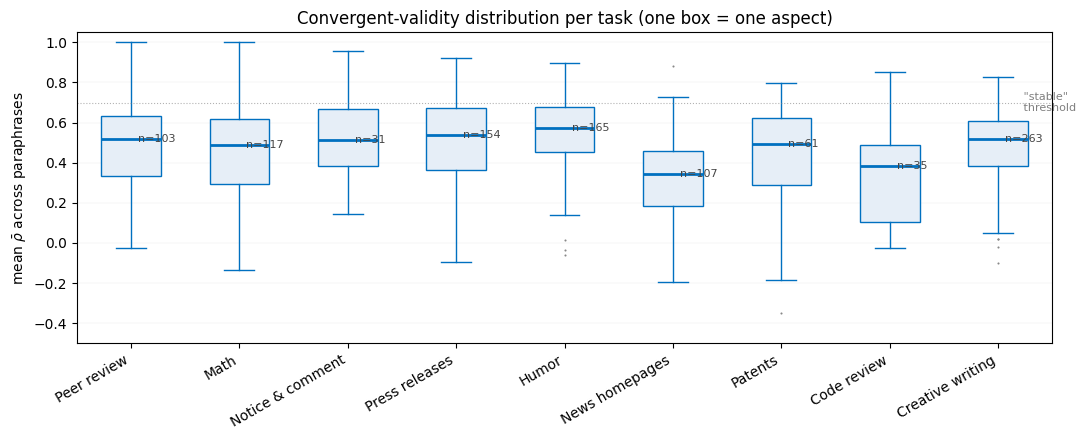

In [4]:
# Distribution of convergent-ρ̄ per task
fig, ax = plt.subplots(figsize=(11, 4.5))
positions = []
for i, t in enumerate(TASKS):
    sub = conv[conv['task']==t]['mean_rho_across_paraphrases'].dropna()
    if sub.empty: continue
    positions.append(i+1)
    bp = ax.boxplot(sub.values, positions=[i+1], widths=0.55, patch_artist=True,
                    boxprops=dict(facecolor='#e6eef7', edgecolor='#0070c0'),
                    medianprops=dict(color='#0070c0', linewidth=2),
                    whiskerprops=dict(color='#0070c0'), capprops=dict(color='#0070c0'),
                    flierprops=dict(marker='.', markerfacecolor='#888', markersize=3, markeredgecolor='none'))
    ax.text(i+1, sub.median(), f'  n={len(sub)}', va='center', fontsize=8, color='#444')

ax.set_xticks(range(1, len(TASKS)+1))
ax.set_xticklabels([TASK_PRETTY[t] for t in TASKS], rotation=30, ha='right')
ax.set_ylabel(r'mean $\bar\rho$ across paraphrases')
ax.axhline(0.7, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.text(len(TASKS)+0.2, 0.7, ' "stable"\n threshold', fontsize=8, color='gray', va='center')
ax.set_title('Convergent-validity distribution per task (one box = one aspect)')
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
ax.set_ylim(-0.5, 1.05)
plt.tight_layout()
plt.savefig(OUT/'noah_convergent_box.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. G-theory — variance decomposition

Pool every Claude+Qwen score for a task and decompose the score variance across four facets:

- **σ²(dp)** — different datapoints get different aggregate scores (the latent "quality" axis)
- **σ²(aspect)** — different aspects systematically score differently (a hard aspect always pulls lower)
- **σ²(judge)** — Claude vs Qwen disagree on absolute level
- **σ²(paraphrase)** — paraphrased rubrics shift the mean
- **residual** — interaction / noise (mostly the dp × aspect cross-term, where rubric reliability collapses)

The headline finding: **σ²(judge) and σ²(paraphrase) are vanishingly small everywhere**. Judges and
rubric paraphrases barely move the needle. The rubric machinery is *reliable* across those two facets.
Where reliability collapses (creative_writing, code_review) is in the dp × aspect interaction — every
datapoint reacts differently to every aspect, which is exactly what we'd expect when aspects fail
to factor cleanly.


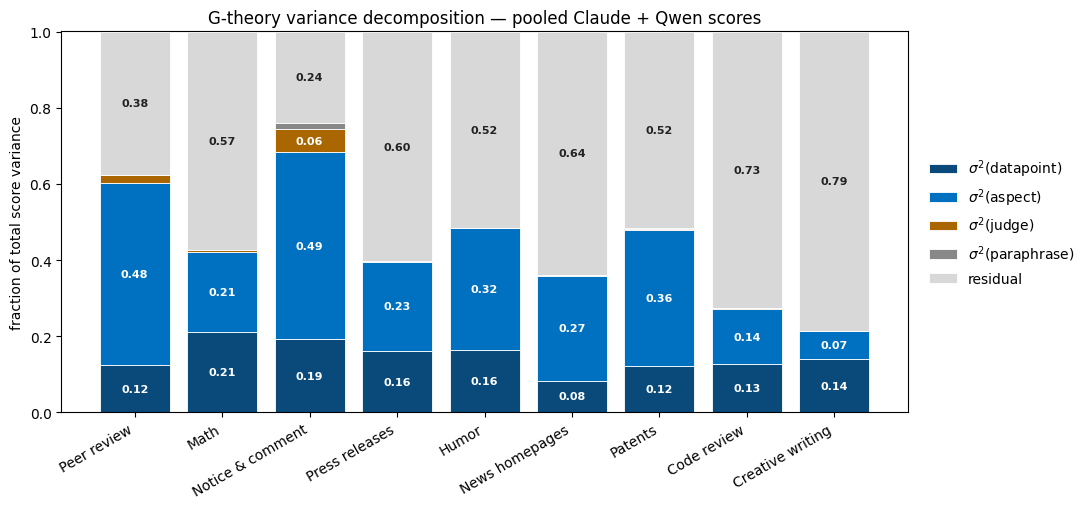

In [5]:
# Stacked-bar G-theory chart
fig, ax = plt.subplots(figsize=(11, 5.2))
g = gth.set_index('task').loc[TASKS]
facets = ['dp', 'aspect', 'judge', 'paraphrase', 'residual']
colors = ['#0a4a7a', '#0070c0', '#aa6600', '#888', '#d8d8d8']
labels = [r'$\sigma^2$(datapoint)', r'$\sigma^2$(aspect)',
          r'$\sigma^2$(judge)', r'$\sigma^2$(paraphrase)', 'residual']
bot = np.zeros(len(g))
xs = np.arange(len(g))
for f, c, l in zip(facets, colors, labels):
    vals = g[f].values
    ax.bar(xs, vals, bottom=bot, color=c, edgecolor='white', linewidth=0.6, label=l)
    # annotate large slices
    for i, v in enumerate(vals):
        if v > 0.04:
            ax.text(xs[i], bot[i]+v/2, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if c not in ('#888','#d8d8d8') else '#222',
                    fontweight='bold')
    bot += vals
ax.set_xticks(xs)
ax.set_xticklabels([TASK_PRETTY[t] for t in TASKS], rotation=30, ha='right')
ax.set_ylabel('fraction of total score variance')
ax.set_title('G-theory variance decomposition — pooled Claude + Qwen scores')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, frameon=False)
ax.set_ylim(0, 1.001)
plt.tight_layout()
plt.savefig(OUT/'noah_g_theory_stacked.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
# Pretty HTML table version
def color_cell(v, scale='blue', maxv=0.5):
    frac = min(1.0, max(0.0, v/maxv))
    if scale == 'blue':
        r,g,b = 230 - int(180*frac), 238 - int(150*frac), 248 - int(40*frac)
    elif scale == 'red':
        r,g,b = 250, 220 - int(160*frac), 220 - int(160*frac)
    elif scale == 'gray':
        r,g,b = 250 - int(40*frac), 250 - int(40*frac), 250 - int(40*frac)
    else:
        r,g,b = 240, 240, 240
    return f'rgb({r},{g},{b})'

rows = []
for t in TASKS:
    r = gth[gth['task']==t].iloc[0]
    cells_html = []
    cells_html.append(f'<td style="padding:8px 12px;font-weight:600">{TASK_PRETTY[t]}</td>')
    cells_html.append(f'<td style="padding:8px 12px;text-align:right;color:#666;font-variant-numeric:tabular-nums">{int(r["n_cells"]):,}</td>')
    for f, scale in [('dp','blue'),('aspect','blue'),('judge','red'),('paraphrase','red'),('residual','gray')]:
        v = r[f]
        bg = color_cell(v, scale=scale, maxv=0.5 if scale!='gray' else 0.8)
        cells_html.append(
            f'<td style="padding:8px 12px;text-align:right;background:{bg};font-variant-numeric:tabular-nums;font-weight:600">{v:.3f}</td>')
    rows.append('<tr>' + ''.join(cells_html) + '</tr>')

header = '''
<thead><tr style="background:#222;color:white;font-size:11px;text-transform:uppercase;letter-spacing:1.5px">
  <th style="padding:10px 12px;text-align:left">Task</th>
  <th style="padding:10px 12px;text-align:right">n cells</th>
  <th style="padding:10px 12px;text-align:right">σ²(dp)</th>
  <th style="padding:10px 12px;text-align:right">σ²(aspect)</th>
  <th style="padding:10px 12px;text-align:right">σ²(judge)</th>
  <th style="padding:10px 12px;text-align:right">σ²(paraphrase)</th>
  <th style="padding:10px 12px;text-align:right">residual</th>
</tr></thead>'''

table = (f'<table style="border-collapse:separate;border-spacing:1px;font-family:-apple-system,Helvetica,Arial,sans-serif;font-size:13px;background:#ddd">'
         f'{header}<tbody>{"".join(rows)}</tbody></table>')

display(HTML(f'<div style="font-family:-apple-system,Helvetica,Arial,sans-serif;max-width:1100px">{table}'
             f'<div style="margin-top:8px;font-size:12px;color:#555">'
             f'Blue = facets we want big (real signal); Red = facets we want small (rater nuisance); '
             f'Gray = residual.'
             f'</div></div>'))

Task,n cells,σ²(dp),σ²(aspect),σ²(judge),σ²(paraphrase),residual
Peer review,"53,793",0.123,0.481,0.019,0.001,0.377
Math,"62,016",0.211,0.210,0.005,0.001,0.572
Notice & comment,"27,855",0.192,0.492,0.061,0.017,0.239
Press releases,"48,193",0.161,0.234,0.000,0.000,0.604
Humor,"63,845",0.164,0.320,0.000,0.001,0.516
News homepages,"57,942",0.083,0.274,0.002,0.001,0.640
Patents,"30,963",0.122,0.358,0.001,0.003,0.516
Code review,"54,402",0.126,0.145,0.003,0.000,0.726
Creative writing,"98,649",0.140,0.074,0.000,0.000,0.786


### Reading the G-theory table

- **σ²(judge) and σ²(paraphrase) hover at 0.00–0.06.** The judges agree on absolute level; paraphrasing the rubric doesn't shift it. The rubric framework itself is internally reliable.
- **σ²(aspect) dominates** on peer_review, NC, patents, humor, NH — aspects do real, separable work.
- **Creative_writing has tiny σ²(aspect)=0.07** — all aspects behave alike there. No clean factor structure; "everything is everything."
- **The residual is where rubric reliability collapses** — it's almost entirely the dp × aspect interaction. Tasks with high residual (CW 0.79, CR 0.73, NH 0.64, press 0.60) are the ones where dense models will dominate any per-aspect approach.

This is the cleanest empirical answer we have to "are LLM-as-judge rubrics reliable as a measurement instrument?": **yes across judge and paraphrase, no across aspect-interactions.**


## Reconstructibility distribution per task

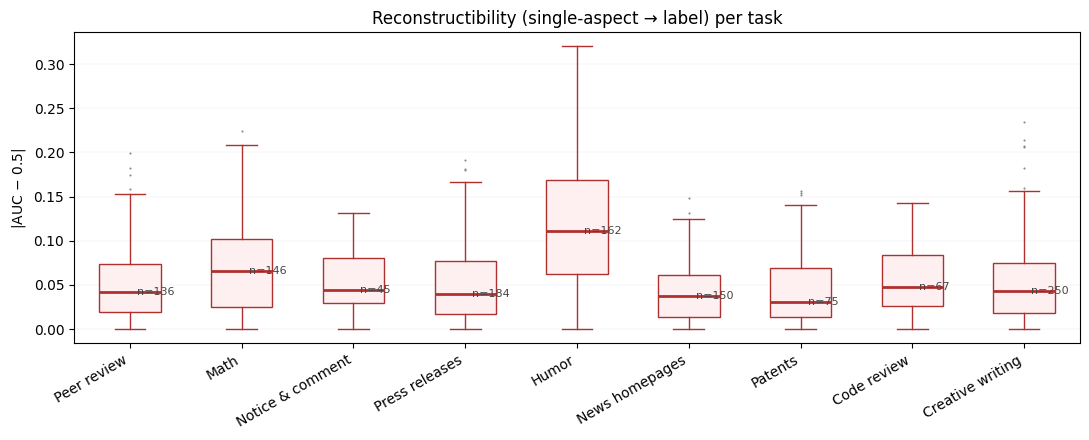

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, t in enumerate(TASKS):
    sub = recon[recon['task']==t]['reconstructibility'].dropna()
    if sub.empty: continue
    bp = ax.boxplot(sub.values, positions=[i+1], widths=0.55, patch_artist=True,
                    boxprops=dict(facecolor='#fef0f0', edgecolor='#b03030'),
                    medianprops=dict(color='#b03030', linewidth=2),
                    whiskerprops=dict(color='#b03030'), capprops=dict(color='#b03030'),
                    flierprops=dict(marker='.', markerfacecolor='#888', markersize=3, markeredgecolor='none'))
    ax.text(i+1, sub.median(), f'  n={len(sub)}', va='center', fontsize=8, color='#444')

ax.set_xticks(range(1, len(TASKS)+1))
ax.set_xticklabels([TASK_PRETTY[t] for t in TASKS], rotation=30, ha='right')
ax.set_ylabel(r'|AUC $-$ 0.5|')
ax.set_title('Reconstructibility (single-aspect → label) per task')
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/'noah_reconstructibility_box.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

| Test | What it answers | Headline |
|---|---|---|
| Reconstructibility | Does a single aspect alone recover the label? | Mostly small effects (|Δ½| < 0.2); humor and creative_writing have the most-reconstructive top aspects. |
| Convergent validity | Are scores stable to rubric paraphrase? | Yes — top aspects per task all hit ρ̄ > 0.78. |
| G-theory | Where does score variance live? | σ²(judge) and σ²(paraphrase) ≈ 0 — protocol is reliable across those facets. Residual (dp × aspect) is the failure mode. |

All outputs cached to `outputs/noah_meeting/`:
- `reconstructibility.csv`, `convergent_validity.csv`, `g_theory.csv`
- PNGs: `noah_reconstructibility_box.png`, `noah_convergent_box.png`, `noah_g_theory_stacked.png`
